# 💉 Diabetes Prediction
### Logistic Regression — Pima Indians Diabetes Dataset

Importing libaries

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Importing Dataset

In [49]:
dataset = pd.read_csv('diabetes.csv')
dataset.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Data Cleaning

In [50]:
print(dataset.isnull().sum())

zero_check = (dataset[['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']] == 0).sum()
print(zero_check)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


Handling Hidden Missing Values

In [51]:
columns_to_fix = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

for col in columns_to_fix:
    dataset[col] = dataset[col].replace(0, dataset[col].median())

zero_check = (dataset[columns_to_fix] == 0).sum()
print(zero_check)

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64


Feature Selection

In [52]:
correlation = dataset.corr()["Outcome"].sort_values(ascending=False)
print(correlation)

features = ["Glucose", "BMI", "Age", "Pregnancies", "DiabetesPedigreeFunction", "BloodPressure", "SkinThickness", "Insulin"]
target = "Outcome"

x = dataset[features]
y = dataset[target]

Outcome                     1.000000
Glucose                     0.492782
BMI                         0.312249
Age                         0.238356
Pregnancies                 0.221898
SkinThickness               0.189065
DiabetesPedigreeFunction    0.173844
BloodPressure               0.165723
Insulin                     0.148457
Name: Outcome, dtype: float64


Spliting Dataset into Training set and Test set

In [53]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Feature Scaling

In [54]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

Training Logistic Regression Model

In [55]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(random_state=0)
model.fit(x_train, y_train)

print("Model trained successfully! ✅")

Model trained successfully! ✅


Model Evaluation

In [56]:
from sklearn.metrics import accuracy_score, recall_score, precision_score
y_pred = model.predict(x_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.2f}")
print(f"Precision: {precision_score(y_test, y_pred):.2f}")
print(f"Recall: {recall_score(y_test, y_pred):.2f}")

Accuracy: 0.77
Precision: 0.68
Recall: 0.65


Confusion Matrix

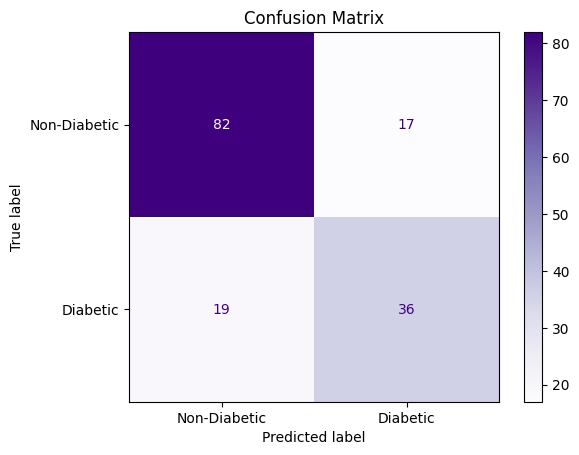

In [57]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Non-Diabetic", "Diabetic"])
disp.plot(cmap='Purples')
plt.title("Confusion Matrix")
plt.show()

Feature Importance

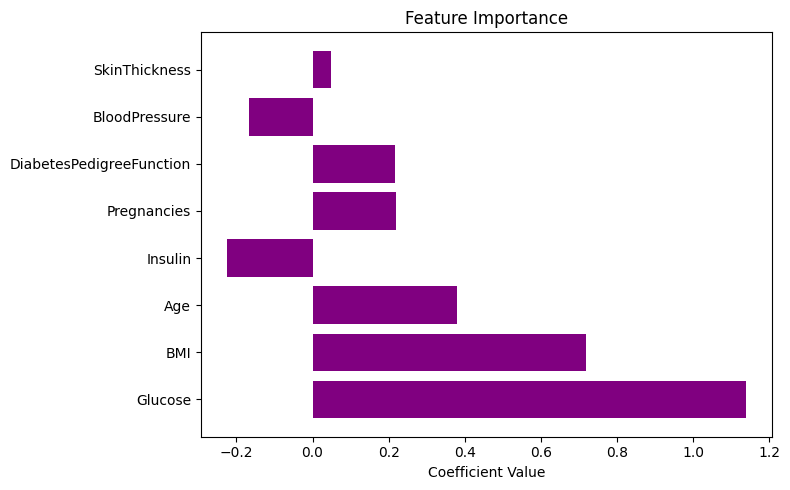

In [58]:
importance = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", key=abs, ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Coefficient"], color="purple")
plt.xlabel("Coefficient Value")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()